In [14]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.insert(0, str(project_root))
# sys.path.insert(0, "/Users/callebrouwer/Desktop/portfolio-analyst-projects/customer-churn-analysis")
from src.data_loader import (load_csv, save_csv)
from src.config import (CHURN_CLEAN_FILE, CHURN_CLEAN_DASHBOARD_FILE)
from src.plot import (plot_churn_summary, plot_box_churn)
from src.function import build_segment_churn_table

In [15]:
df = load_csv(CHURN_CLEAN_FILE)


# Customer Churn Exploratory Analysis

The objective of this analysis is to identify the main drivers of customer churn and translate those findings into practical business recommendations. The notebook focuses on customer behavior, pricing, service usage, billing patterns, and contract structure to understand which customer groups are most at risk of leaving.

Overall churn rate: 26.58%
Churn
0    5163
1    1869
Name: count, dtype: int64


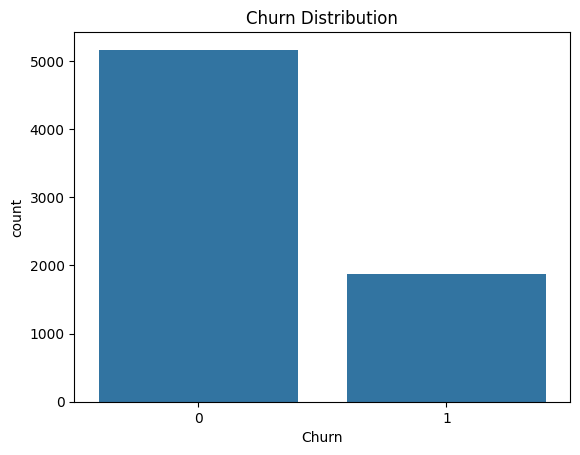

In [16]:
churn_rate = df['Churn'].mean()
churn_count = df['Churn'].value_counts()

print(f"Overall churn rate: {churn_rate:.2%}")
print(churn_count)
sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

## Churn overview

The overall churn rate is **26.6%**, which means roughly 1 in 4 customers have left the service. This is high enough to justify a deeper investigation into customer retention drivers.

The distribution also shows that non-churned customers still make up the majority of the dataset, but the churn segment is large enough to have meaningful business impact. Reducing churn even slightly could improve revenue stability and customer lifetime value.

# Correlation with churn (numeric variables)

The correlation analysis gives an early indication of which numeric features are most associated with churn. It does not prove causation, but it helps identify the variables worth investigating in more detail.

The strongest negative relationship is with **tenure**, suggesting that customers who stay longer are much less likely to churn. **TotalCharges** also has a negative relationship with churn, which supports the idea that long-term customers are more stable. On the other hand, **MonthlyCharges** and **PaperlessBilling** show positive relationships with churn, indicating that customers paying more per month or using paperless billing may be more likely to leave.

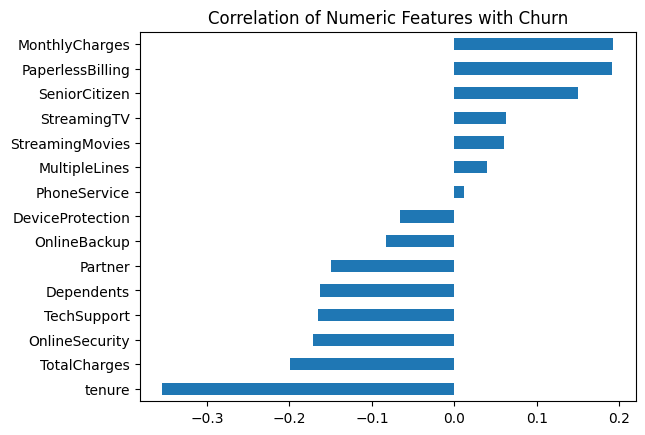

In [17]:
corr = df.corr(numeric_only=True)['Churn'].drop('Churn').sort_values()
corr.plot(kind='barh')
plt.title('Correlation of Numeric Features with Churn')
plt.show()

# Tenure analysis

/var/folders/0m/gbwrf68d7x1d396vdkq6b3940000gn/T/ipykernel_61336/4037182405.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('tenure_group')['Churn'].mean()
/Users/callebrouwer/Desktop/portfolio-analyst-projects/customer-churn-analysis/src/plot.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = df.groupby(col)['Churn'].value_counts().unstack()
/Users/callebrouwer/Desktop/portfolio-analyst-projects/customer-churn-analysis/src/plot.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain curr

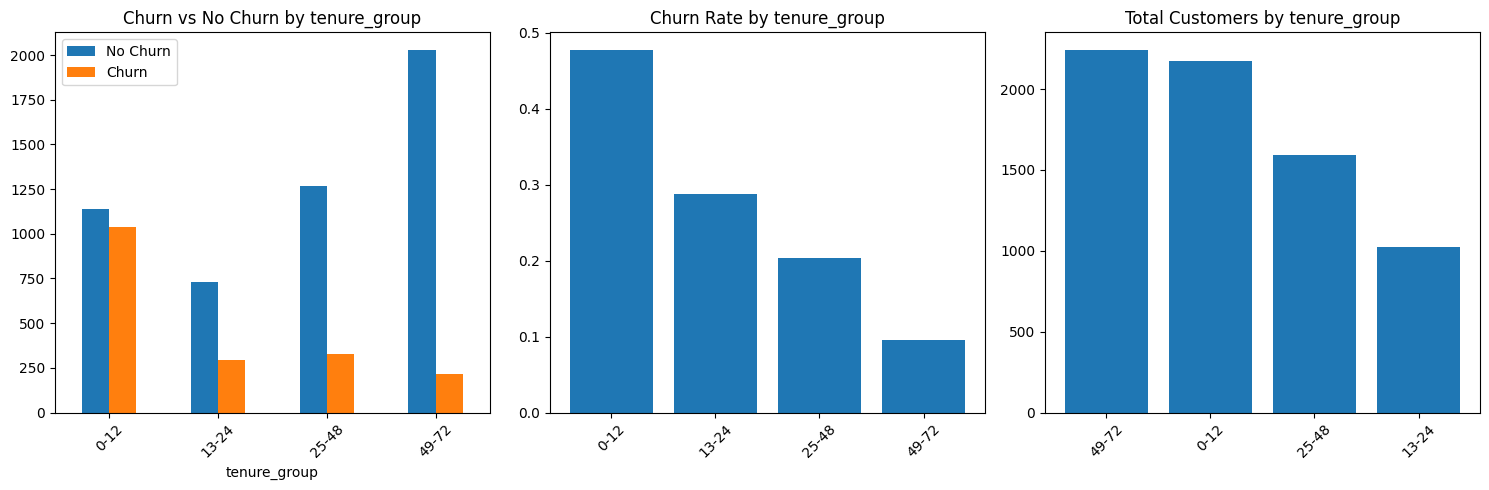

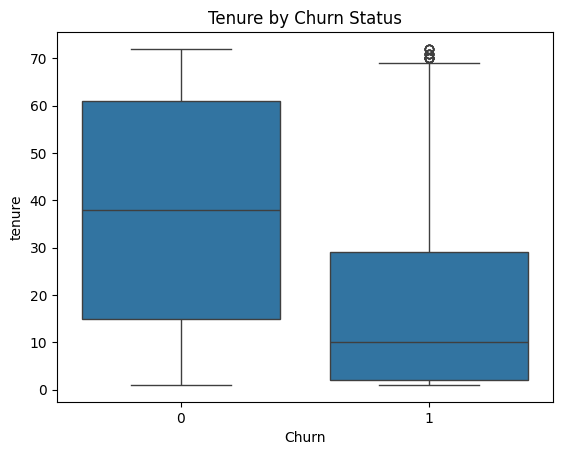

In [18]:
df['tenure_group'] = pd.cut(
    df['tenure'],
    bins=[0,12, 24, 48, 72],
    labels=['0-12','13-24','25-48','49-72']
)

df.groupby('tenure_group')['Churn'].mean()
plot_churn_summary(df, 'tenure_group')
plot_box_churn('Churn','tenure',df)

## Tenure insights

Tenure is one of the strongest churn indicators in the dataset. Customers in the **0–12 month** group have the highest churn rate at **47.7%**, while customers in the **49–72 month** group have a much lower churn rate of **9.5%**.

This suggests that churn risk is heavily concentrated in the early stage of the customer lifecycle. From a business perspective, this points to onboarding, early customer experience, and first-year retention efforts as high-priority areas.

# Pricing analysis

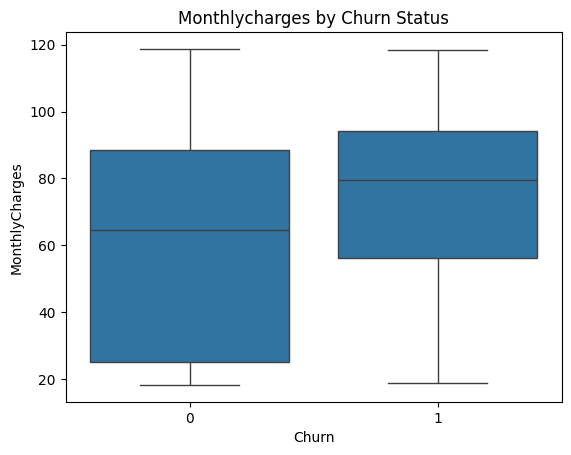

In [19]:
plot_box_churn('Churn', 'MonthlyCharges',df)

## Monthly pricing insights

The boxplot shows that customers who churn tend to have **higher monthly charges** than customers who stay. This indicates that pricing, perceived value, or plan structure may be contributing to churn.

Higher charges do not automatically cause churn, but they may increase sensitivity to service quality, support experience, or competitor offers. Customers paying more are likely to have higher expectations, so retention strategies should focus on making sure those customers clearly see value in the service.

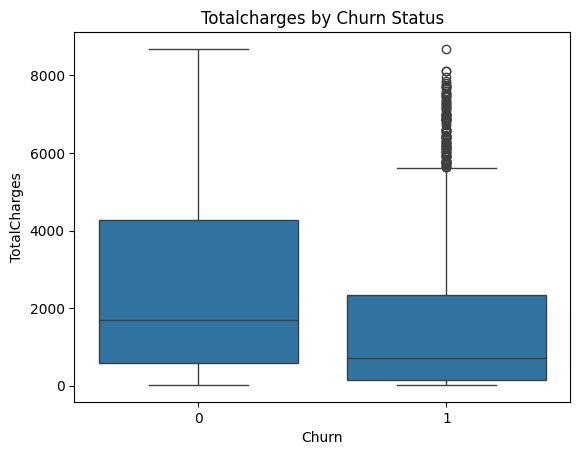

In [20]:
plot_box_churn('Churn', 'TotalCharges', df)

## Total charges insights

Customers who remained with the company generally show higher total charges than customers who churned. This is consistent with the tenure analysis, since total charges tend to increase the longer a customer stays with the company.

The result suggests that churn is concentrated among customers earlier in their lifecycle, before they generate high lifetime value. From a business perspective, this reinforces the importance of retaining customers during the first months of the relationship.

# Support and protection services analysis

In [21]:
for col in ['TechSupport', 'OnlineSecurity', 'PaperlessBilling']:
    print(df.groupby(col)['Churn'].mean())

TechSupport
0    0.312300
1    0.151961
Name: Churn, dtype: float64
OnlineSecurity
0    0.313733
1    0.146402
Name: Churn, dtype: float64
PaperlessBilling
0    0.163757
1    0.335893
Name: Churn, dtype: float64


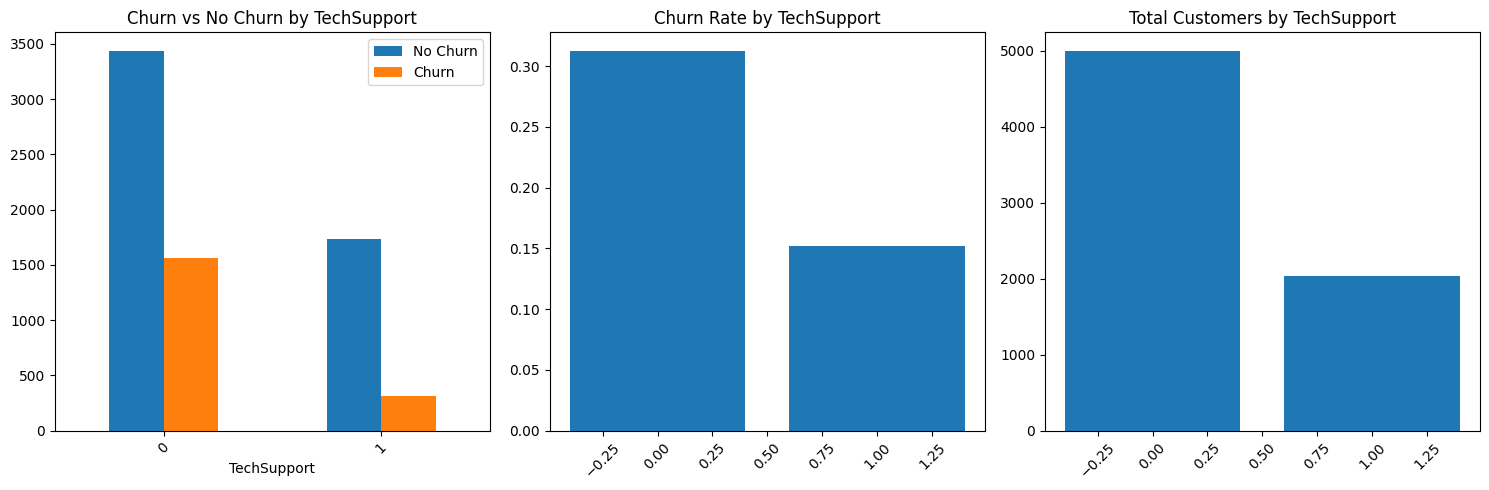

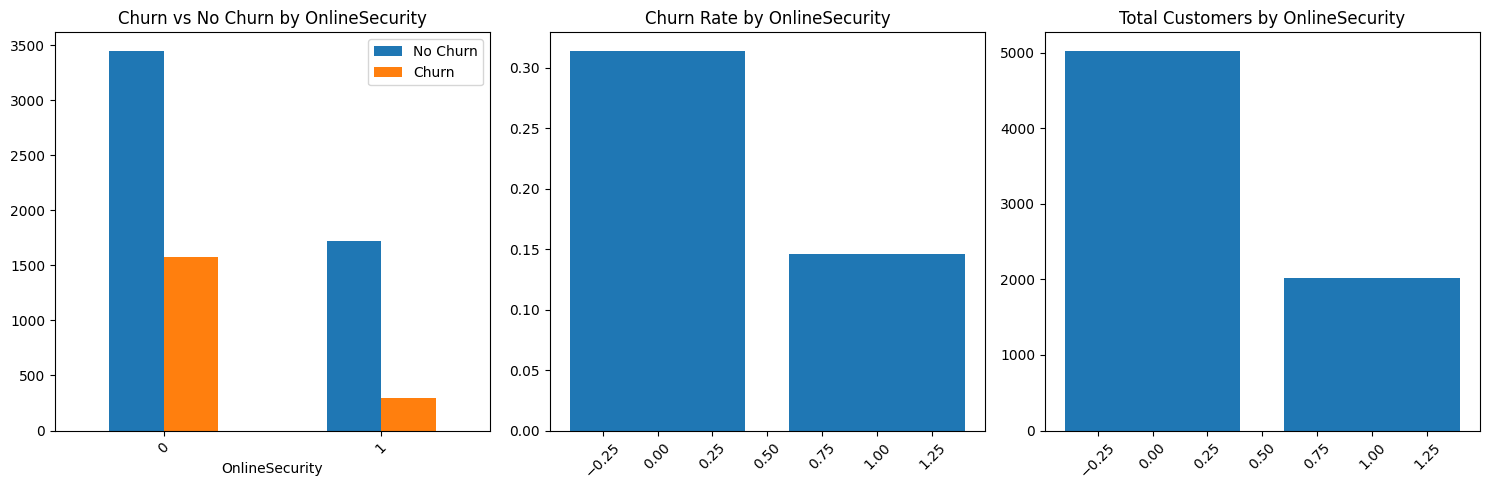

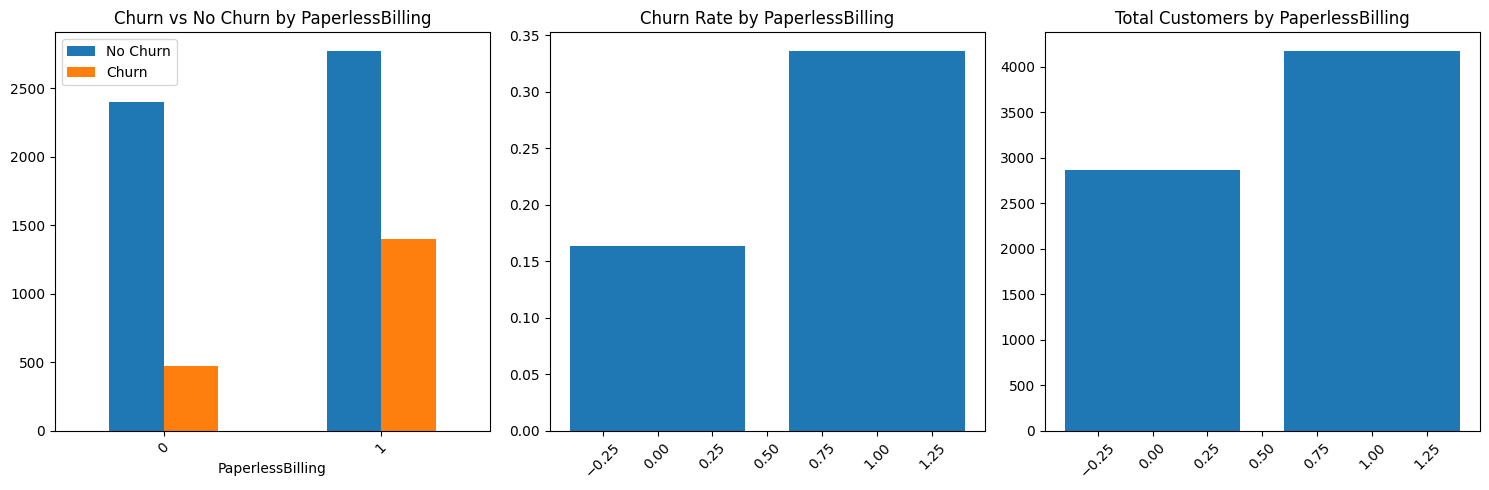

In [22]:
plot_churn_summary(df, 'TechSupport')
plot_churn_summary(df, 'OnlineSecurity')
plot_churn_summary(df, 'PaperlessBilling')

## Support and protection service insights

Customers without **TechSupport** have a churn rate of **31.2%**, compared with **15.2%** for those who have it. A similar pattern appears for **OnlineSecurity**, where customers without the service churn at **31.4%**, compared with **14.6%** for customers who do have it.

This suggests that support and protection services may play an important role in customer retention. These services may either improve customer satisfaction directly or be associated with customers who are more engaged and more invested in the product.

# Key categorical drivers of churn

This section examines the main categorical features most strongly associated with churn: contract type, internet service, and payment method. These variables are especially important because they are highly actionable from a business point of view.

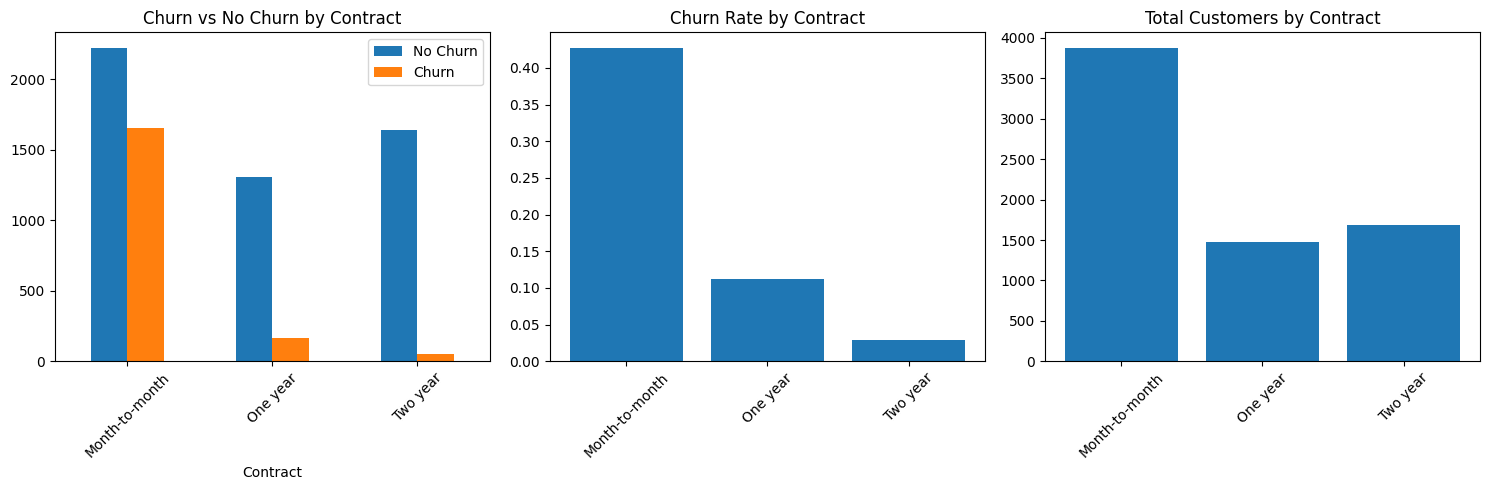

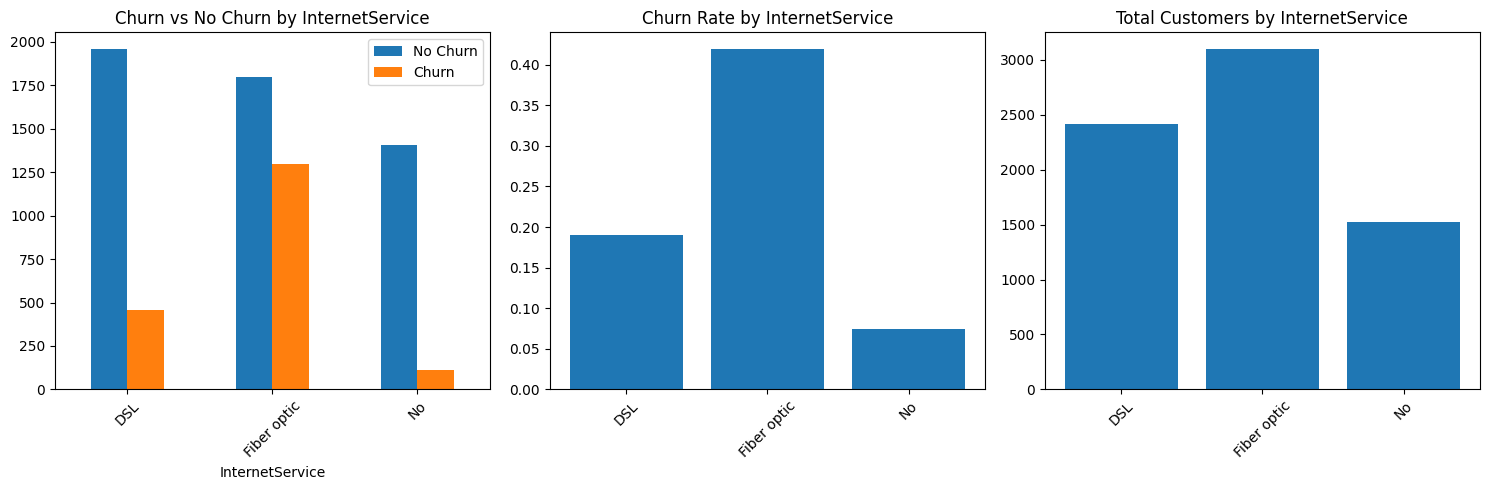

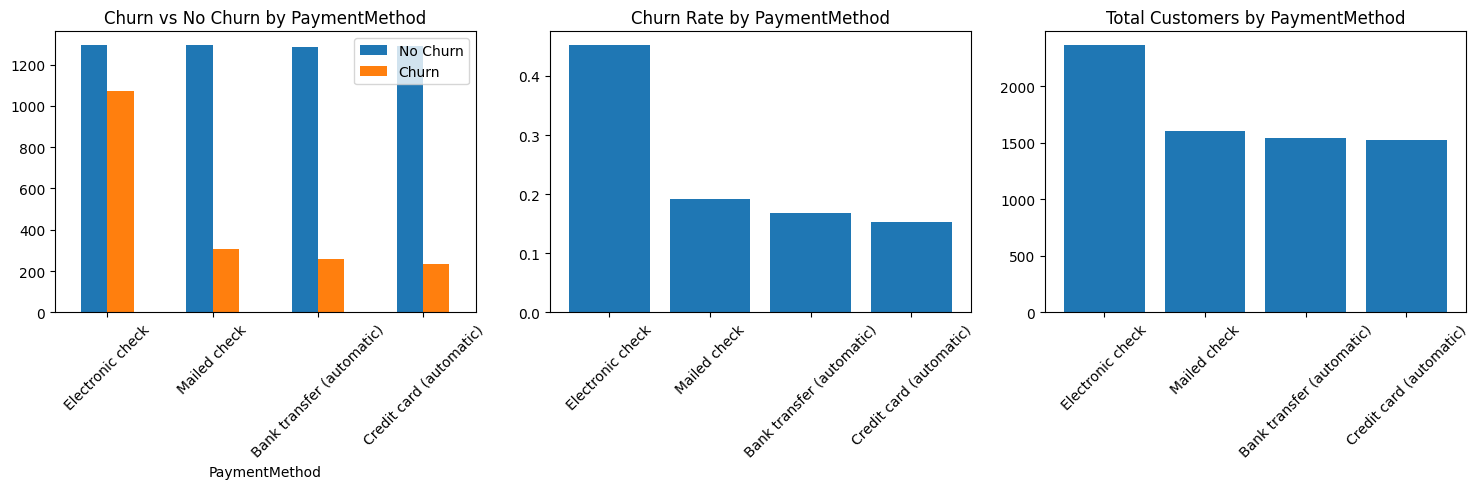

In [23]:
plot_churn_summary(df, 'Contract', order=['Month-to-month', 'One year', 'Two year'])
plot_churn_summary(df, 'InternetService', order=['DSL', 'Fiber optic', 'No'])
plot_churn_summary(df, 'PaymentMethod', order=['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)'])


## Contract, service, and billing insights

**Contract type** is one of the clearest churn drivers in the dataset. Customers on **month-to-month contracts** have a churn rate of **42.7%**, compared with **11.3%** for one-year contracts and only **2.8%** for two-year contracts. This strongly suggests that customers with low commitment are much more likely to leave.

**Internet service type** also matters. Customers using **fiber optic** service show the highest churn rate at **41.9%**, compared with **19.0%** for DSL and **7.4%** for customers with no internet service. This may indicate service quality concerns, pricing pressure, or unmet expectations among fiber customers.

**Payment method** shows another strong pattern. Customers using **electronic check** have a churn rate of **45.3%**, much higher than customers using automatic payment methods such as bank transfer (**16.7%**) or credit card (**15.3%**). This may reflect lower engagement, less convenience, or a customer segment that is easier to lose.

# Demographic analysis

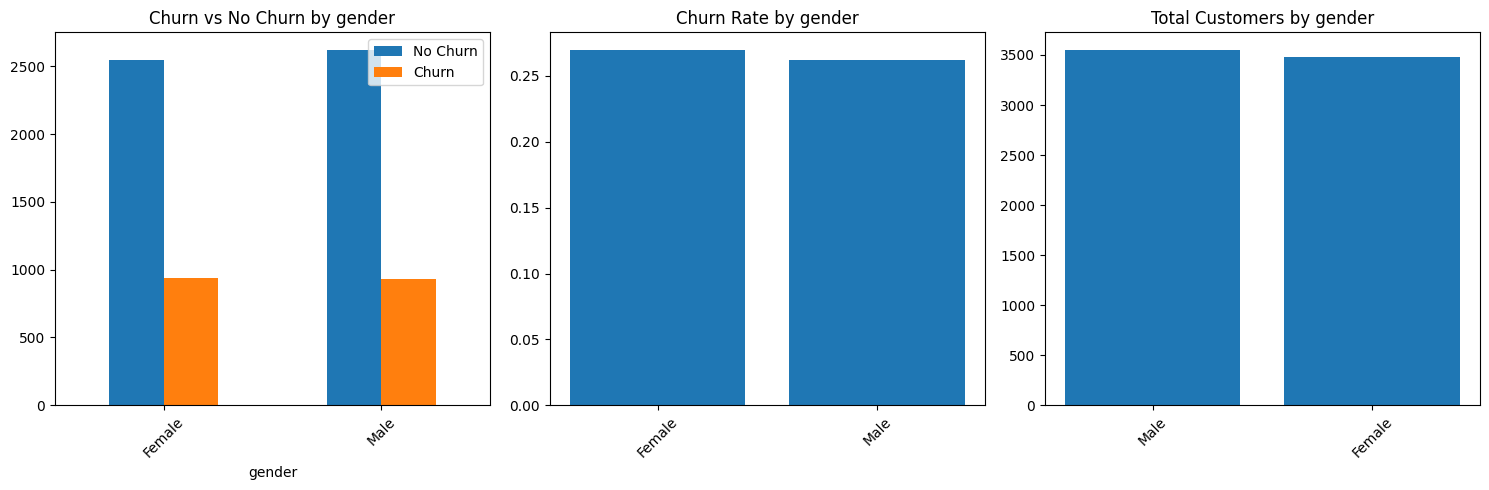

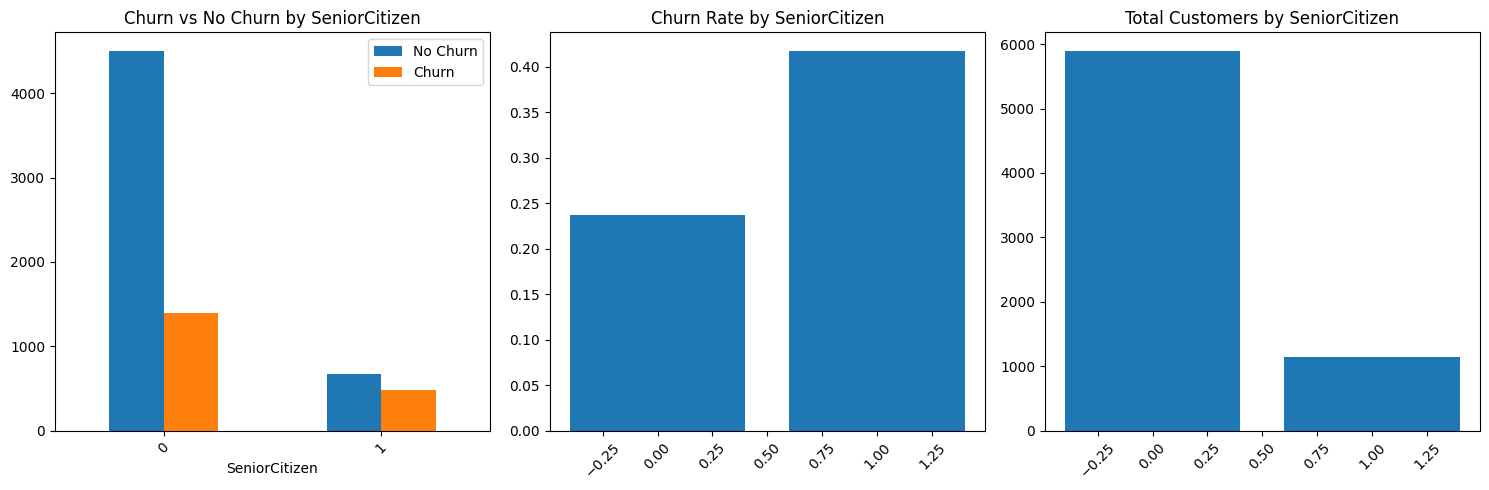

In [24]:
plot_churn_summary(df, 'gender')
plot_churn_summary(df, 'SeniorCitizen')

## Demographic insights

Gender does not appear to be a meaningful churn driver in this dataset. The churn rate is very similar for female and male customers, so gender should not be treated as a priority segmentation variable.

Senior citizens, however, show a noticeably higher churn rate (**41.7%**) than non-senior customers (**23.7%**). This suggests that age-related needs, service expectations, pricing sensitivity, or support quality may be worth investigating further for this customer group.

# Combined segment analysis

To better understand which customers are most at risk, I analyzed churn across combinations of contract type, internet service, and tenure group. This segment-level view helps identify where churn risk is most concentrated.

The highest-risk segment is customers on **month-to-month contracts with fiber optic service in the first 12 months**, where churn is especially high. In contrast, customers on **longer-term contracts** generally show much lower churn across most tenure groups.

Each cell shows the churn rate, followed by the number of churned customers over the total number of customers in the segment.

In [25]:
rate_table = build_segment_churn_table(df,index_cols=['Contract','InternetService'],column_col='tenure_group')


# Final conclusions and business recommendations

## Key findings

The analysis shows that churn is driven mainly by a combination of **customer lifecycle stage, contract structure, pricing, service usage, and billing behavior**.

The clearest patterns are:

- Customers with **short tenure** are much more likely to churn than long-term customers.
- Customers on **month-to-month contracts** have the highest churn risk by a large margin.
- Customers with **higher monthly charges** are more likely to churn.
- Customers without **TechSupport** or **OnlineSecurity** are substantially more likely to leave.
- Customers using **fiber optic service** and **electronic check** also show elevated churn rates.
- **Gender** does not appear to meaningfully affect churn, while **SeniorCitizen** does show a notable difference.

## Business recommendations

Based on these findings, the business should prioritize retention efforts in the following areas:

1. **Focus on new customers in the first 12 months**  
   Early churn is the biggest risk area, so onboarding and first-year engagement should be improved.

2. **Promote longer-term contracts**  
   Encourage customers to move from month-to-month plans to one-year or two-year contracts using targeted incentives.

3. **Review value perception for high-charge customers**  
   Customers paying more per month may need stronger service quality, clearer plan benefits, or more personalized retention efforts.

4. **Bundle or promote support and security services**  
   Customers with TechSupport and OnlineSecurity churn much less, so these services may help improve retention.

5. **Investigate electronic check and fiber optic customers more closely**  
   These segments have especially high churn and may require more targeted research and retention action.

In [26]:
save_csv(df, CHURN_CLEAN_DASHBOARD_FILE)